In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
PATH = 'slooze_challenge./'

sales     = pd.read_csv(PATH + 'SalesFINAL12312016.csv')
purchases = pd.read_csv(PATH + 'PurchasesFINAL12312016.csv')
beg_inv   = pd.read_csv(PATH + 'BegInvFINAL12312016.csv')
end_inv   = pd.read_csv(PATH + 'EndInvFINAL12312016.csv')
invoices  = pd.read_csv(PATH + 'InvoicePurchases12312016.csv')
prices    = pd.read_csv(PATH + '2017PurchasePricesDec.csv')

print('sales:    ', sales.shape)
print('purchases:', purchases.shape)
print('beg_inv:  ', beg_inv.shape)
print('end_inv:  ', end_inv.shape)
print('invoices: ', invoices.shape)
print('prices:   ', prices.shape)

sales:     (1048575, 14)
purchases: (2372474, 16)
beg_inv:   (206529, 9)
end_inv:   (224489, 9)
invoices:  (5543, 10)
prices:    (12261, 9)


In [3]:
sales.head(3)

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,1/1/2016,750,1,0.79,12546,JIM BEAM BRANDS COMPANY
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2,32.98,16.49,1/2/2016,750,1,1.57,12546,JIM BEAM BRANDS COMPANY
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,1/3/2016,750,1,0.79,12546,JIM BEAM BRANDS COMPANY


In [4]:
purchases.head(3)

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2015-12-21,2016-01-02,2016-01-04,2016-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2015-12-22,2016-01-01,2016-01-07,2016-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2015-12-22,2016-01-02,2016-01-07,2016-02-21,9.41,5,47.05,1


In [5]:
prices.head(3)

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP


In [6]:
sales['SalesDate'] = pd.to_datetime(sales['SalesDate'], format='mixed')

for col in ['PODate', 'ReceivingDate', 'InvoiceDate', 'PayDate']:
    purchases[col] = pd.to_datetime(purchases[col])

invoices['InvoiceDate'] = pd.to_datetime(invoices['InvoiceDate'])
invoices['PODate']      = pd.to_datetime(invoices['PODate'])
invoices['PayDate']     = pd.to_datetime(invoices['PayDate'])

beg_inv['startDate'] = pd.to_datetime(beg_inv['startDate'])
end_inv['endDate']   = pd.to_datetime(end_inv['endDate'])

for df in [sales, purchases, invoices, prices]:
    str_cols = df.select_dtypes('object').columns
    df[str_cols] = df[str_cols].apply(lambda c: c.str.strip())

print('date range in sales:', sales['SalesDate'].min().date(), '-->', sales['SalesDate'].max().date())
print('date range in purchases:', purchases['PODate'].min().date(), '-->', purchases['PODate'].max().date())

date range in sales: 2016-01-01 --> 2016-02-29
date range in purchases: 2015-12-20 --> 2016-12-23


In [7]:
dfs = {'sales': sales, 'purchases': purchases, 'beg_inv': beg_inv,
       'end_inv': end_inv, 'invoices': invoices, 'prices': prices}

for name, df in dfs.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) == 0:
        print(f'{name}: no missing values')
    else:
        print(f'\n{name}:')
        for col, n in missing.items():
            print(f'  {col}: {n} nulls ({n/len(df)*100:.1f}%)')

sales: no missing values

purchases:
  Size: 3 nulls (0.0%)
beg_inv: no missing values

end_inv:
  City: 1284 nulls (0.6%)

invoices:
  Approval: 5169 nulls (93.3%)

prices:
  Description: 1 nulls (0.0%)
  Size: 1 nulls (0.0%)
  Volume: 1 nulls (0.0%)


In [8]:
store_city = beg_inv.drop_duplicates('Store').set_index('Store')['City']
end_inv['City'] = end_inv['City'].fillna(end_inv['Store'].map(store_city))
print('remaining city nulls in end_inv:', end_inv['City'].isnull().sum())

print('invoices Approval non-null count:', invoices['Approval'].notna().sum())

remaining city nulls in end_inv: 0
invoices Approval non-null count: 374


In [9]:
print('=== SALES ===')
print(sales[['SalesQuantity', 'SalesDollars', 'SalesPrice', 'ExciseTax']].describe().round(2))

=== SALES ===
       SalesQuantity  SalesDollars  SalesPrice   ExciseTax
count     1048575.00    1048575.00  1048575.00  1048575.00
mean            2.34         31.60       15.43        1.33
std             3.51         65.70       14.05        3.41
min             1.00          0.49        0.49        0.01
25%             1.00         10.99        8.99        0.16
50%             1.00         17.99       12.99        0.68
75%             2.00         31.99       18.99        1.57
max           432.00      13279.97     4999.99      378.52


In [10]:
print('=== PURCHASES ===')
print(purchases[['Quantity', 'Dollars', 'PurchasePrice']].describe().round(2))

=== PURCHASES ===
         Quantity     Dollars  PurchasePrice
count  2372474.00  2372474.00     2372474.00
mean        14.16      135.68          12.05
std         23.45      281.66          17.95
min          1.00        0.00           0.00
25%          6.00       49.26           6.12
50%         10.00       83.93           9.22
75%         12.00      140.52          14.49
max       3816.00    50175.70        5681.81


In [11]:
total_revenue   = sales['SalesDollars'].sum()
total_purchases = purchases['Dollars'].sum()
total_units_sold = sales['SalesQuantity'].sum()
n_stores  = sales['Store'].nunique()
n_products = sales['Brand'].nunique()
n_vendors = purchases['VendorNumber'].nunique()

print(f'Total Revenue:       ${total_revenue:,.0f}')
print(f'Total Purchase Cost: ${total_purchases:,.0f}')
print(f'Est. Gross Profit:   ${total_revenue - total_purchases:,.0f}')
print(f'Units Sold:          {total_units_sold:,}')
print(f'Unique Stores:       {n_stores}')
print(f'Unique Products:     {n_products}')
print(f'Unique Vendors:      {n_vendors}')

Total Revenue:       $33,139,375
Total Purchase Cost: $321,900,766
Est. Gross Profit:   $-288,761,390
Units Sold:          2,451,169
Unique Stores:       79
Unique Products:     7658
Unique Vendors:      126


In [12]:
brand_cost = prices.groupby('Brand')['PurchasePrice'].median().reset_index()
brand_cost.columns = ['Brand', 'UnitCost']

sales = sales.merge(brand_cost, on='Brand', how='left')
sales['TotalCost']   = sales['UnitCost'] * sales['SalesQuantity']
sales['GrossProfit'] = sales['SalesDollars'] - sales['TotalCost']
sales['Margin']      = sales['GrossProfit'] / sales['SalesDollars'] * 100

match_rate = sales['UnitCost'].notna().mean() * 100
print(f'Match rate with price table: {match_rate:.1f}%')
print(f'Median margin: {sales["Margin"].median():.1f}%')

Match rate with price table: 100.0%
Median margin: 31.9%


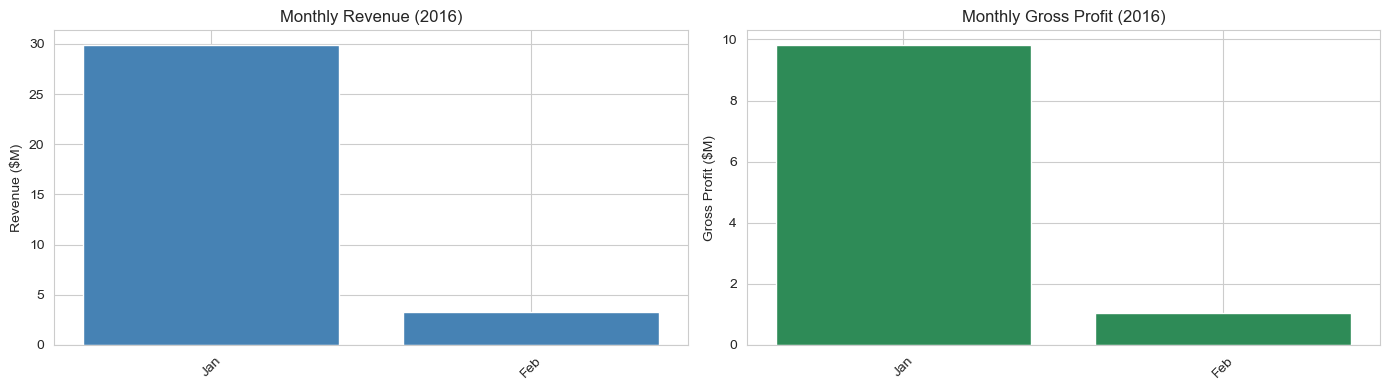

Peak month: Jan with $29.85M


In [13]:
monthly = (
    sales.set_index('SalesDate')
    .resample('ME')
    .agg(Revenue=('SalesDollars','sum'),
         GrossProfit=('GrossProfit','sum'),
         Units=('SalesQuantity','sum'))
    .reset_index()
)
monthly['month_label'] = monthly['SalesDate'].dt.strftime('%b')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(monthly['month_label'], monthly['Revenue'] / 1e6, color='steelblue')
axes[0].set_title('Monthly Revenue (2016)')
axes[0].set_ylabel('Revenue ($M)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(monthly['month_label'], monthly['GrossProfit'] / 1e6, color='seagreen')
axes[1].set_title('Monthly Gross Profit (2016)')
axes[1].set_ylabel('Gross Profit ($M)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('plot_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

peak = monthly.loc[monthly['Revenue'].idxmax()]
print(f'Peak month: {peak["month_label"]} with ${peak["Revenue"]/1e6:.2f}M')

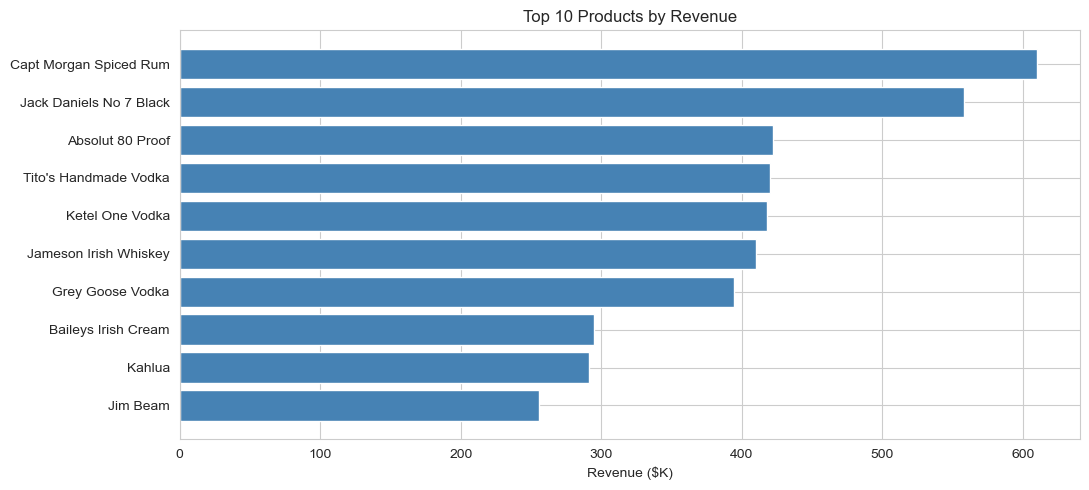

            Description   Revenue  Units    Margin
 Capt Morgan Spiced Rum 610008.34  35866 26.130653
Jack Daniels No 7 Black 558064.03  23797 27.020785
       Absolut 80 Proof 422095.29  23171 29.819161
  Tito's Handmade Vodka 420186.25  20125 31.054606
        Ketel One Vodka 417950.59  15721 27.009003
  Jameson Irish Whiskey 410287.84  17016 26.744463
       Grey Goose Vodka 394280.19  15481 25.927470
    Baileys Irish Cream 294738.43  17307 28.140704
                 Kahlua 290933.11  16389 27.883714
               Jim Beam 255837.61  21239 28.187919


In [14]:
top_products = (
    sales.groupby('Description')
    .agg(Revenue=('SalesDollars','sum'),
         Units=('SalesQuantity','sum'),
         Margin=('Margin','median'))
    .reset_index()
    .sort_values('Revenue', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(11, 5))
labels = [d[:35] + '...' if len(d) > 35 else d for d in top_products['Description']]
ax.barh(labels[::-1], top_products['Revenue'].values[::-1] / 1e3, color='steelblue')
ax.set_xlabel('Revenue ($K)')
ax.set_title('Top 10 Products by Revenue')
plt.tight_layout()
plt.savefig('plot_top10_products.png', dpi=150, bbox_inches='tight')
plt.show()

print(top_products[['Description','Revenue','Units','Margin']].to_string(index=False))

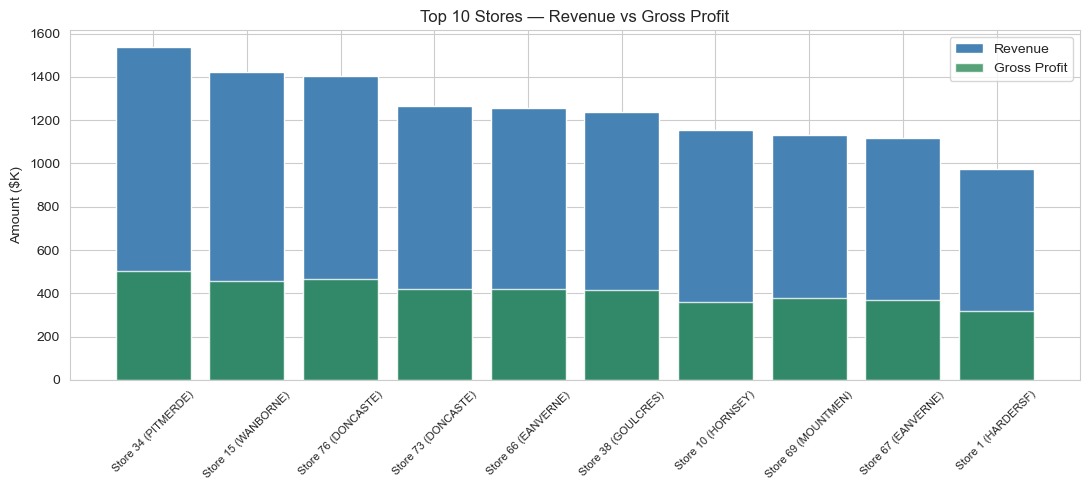

In [15]:
store_city_map = beg_inv.drop_duplicates('Store')[['Store','City']]

top_stores = (
    sales.groupby('Store')
    .agg(Revenue=('SalesDollars','sum'),
         GrossProfit=('GrossProfit','sum'),
         Transactions=('SalesDollars','count'))
    .reset_index()
    .merge(store_city_map, on='Store', how='left')
    .sort_values('Revenue', ascending=False)
    .head(10)
)

store_labels = [f"Store {int(r['Store'])} ({r['City'][:8]})" for _, r in top_stores.iterrows()]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(store_labels, top_stores['Revenue'] / 1e3, color='steelblue', label='Revenue')
ax.bar(store_labels, top_stores['GrossProfit'] / 1e3, color='seagreen', alpha=0.8, label='Gross Profit')
ax.set_ylabel('Amount ($K)')
ax.set_title('Top 10 Stores — Revenue vs Gross Profit')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.legend()
plt.tight_layout()
plt.savefig('plot_top10_stores.png', dpi=150, bbox_inches='tight')
plt.show()

Top 3 vendors account for 32.0% of total spend — worth watching


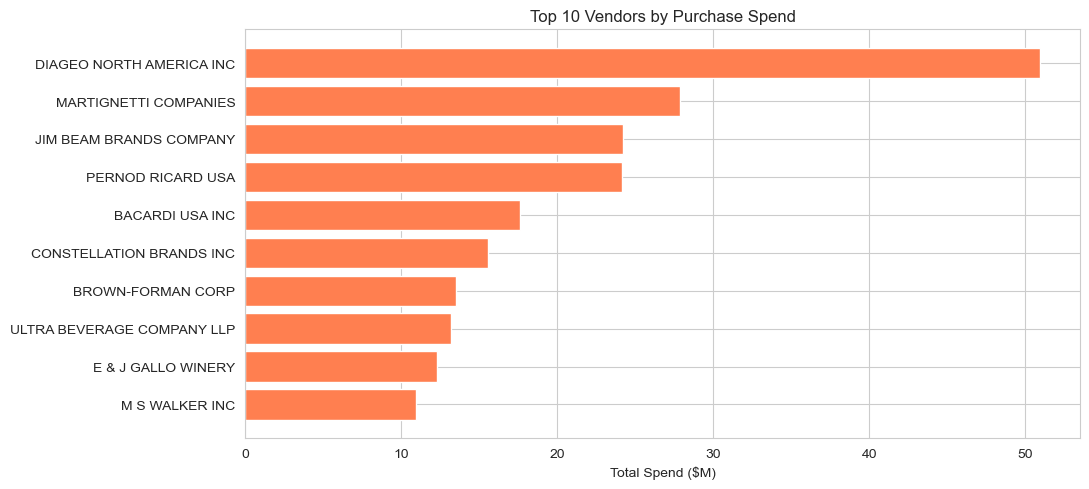

In [16]:
top_vendors = (
    purchases.groupby('VendorName')
    .agg(TotalSpend=('Dollars','sum'),
         TotalUnits=('Quantity','sum'),
         Orders=('PONumber','nunique'))
    .reset_index()
    .sort_values('TotalSpend', ascending=False)
    .head(10)
)

top3_share = top_vendors.head(3)['TotalSpend'].sum() / purchases['Dollars'].sum() * 100
print(f'Top 3 vendors account for {top3_share:.1f}% of total spend — worth watching')

fig, ax = plt.subplots(figsize=(11, 5))
names = [n[:28] + '...' if len(n) > 28 else n for n in top_vendors['VendorName']]
ax.barh(names[::-1], top_vendors['TotalSpend'].values[::-1] / 1e6, color='coral')
ax.set_xlabel('Total Spend ($M)')
ax.set_title('Top 10 Vendors by Purchase Spend')
plt.tight_layout()
plt.savefig('plot_top10_vendors.png', dpi=150, bbox_inches='tight')
plt.show()

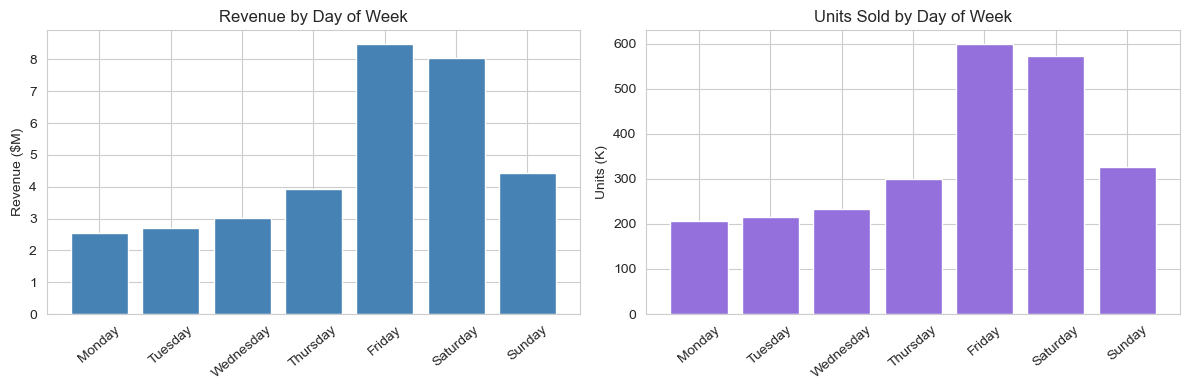

In [17]:
sales['dow'] = sales['SalesDate'].dt.day_name()
sales['dow_num'] = sales['SalesDate'].dt.dayofweek

dow_sales = (
    sales.groupby(['dow','dow_num'])
    .agg(Revenue=('SalesDollars','sum'), Units=('SalesQuantity','sum'))
    .reset_index()
    .sort_values('dow_num')
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(dow_sales['dow'], dow_sales['Revenue'] / 1e6, color='steelblue')
ax1.set_title('Revenue by Day of Week')
ax1.set_ylabel('Revenue ($M)')
ax1.tick_params(axis='x', rotation=40)

ax2.bar(dow_sales['dow'], dow_sales['Units'] / 1e3, color='mediumpurple')
ax2.set_title('Units Sold by Day of Week')
ax2.set_ylabel('Units (K)')
ax2.tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.savefig('plot_dow_sales.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
inv_merged = beg_inv[['InventoryId','Brand','Description','onHand','Price']].merge(
    end_inv[['InventoryId','onHand','Price']],
    on='InventoryId', suffixes=('_beg','_end')
)

inv_merged['stock_change'] = inv_merged['onHand_end'] - inv_merged['onHand_beg']

beg_value = (inv_merged['onHand_beg'] * inv_merged['Price_beg']).sum()
end_value = (inv_merged['onHand_end'] * inv_merged['Price_end']).sum()

print(f'Beginning inventory value: ${beg_value:,.0f}')
print(f'Ending inventory value:    ${end_value:,.0f}')
print(f'Change:                    ${end_value - beg_value:+,.0f}')

print('\nTop 10 most depleted products (likely fast movers):')
print(inv_merged.nsmallest(10, 'stock_change')[['Description','onHand_beg','onHand_end','stock_change']].to_string(index=False))

print('\nTop 10 most accumulated (possible slow movers / overstock):')
print(inv_merged.nlargest(10, 'stock_change')[['Description','onHand_beg','onHand_end','stock_change']].to_string(index=False))

Beginning inventory value: $60,721,278
Ending inventory value:    $65,214,823
Change:                    $+4,493,545

Top 10 most depleted products (likely fast movers):
                 Description  onHand_beg  onHand_end  stock_change
           Smirnoff 80 Proof         930         107          -823
           Smirnoff 80 Proof        1163         351          -812
         Smirnoff Watermelon         921         144          -777
            Grey Goose Vodka         818          88          -730
            Grey Goose Vodka        1251         527          -724
           Smirnoff 80 Proof         597          25          -572
Kendall Jackson Chard Vt RSV         706         184          -522
           Smirnoff 80 Proof         541          19          -522
          Dewars White Label         576          93          -483
         Baileys Irish Cream         503          35          -468

Top 10 most accumulated (possible slow movers / overstock):
                 Description  on

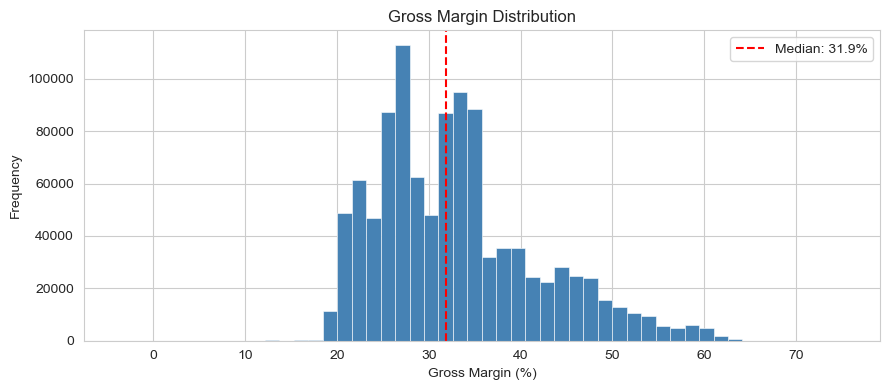

In [19]:
margin_data = sales['Margin'].dropna().clip(-10, 80)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(margin_data, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(sales['Margin'].median(), color='red', linestyle='--', linewidth=1.5,
           label=f'Median: {sales["Margin"].median():.1f}%')
ax.set_xlabel('Gross Margin (%)')
ax.set_ylabel('Frequency')
ax.set_title('Gross Margin Distribution')
ax.legend()
plt.tight_layout()
plt.savefig('plot_margin_dist.png', dpi=150, bbox_inches='tight')
plt.show()